In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import cifar10

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [3]:
np.random.seed(42)

In [4]:
tf.random.set_seed(42)

In [5]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [6]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


In [7]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
BATCH_SIZE = 32

In [8]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

In [12]:
history = model.fit(
    x_train, y_train,
    epochs=25,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.2711 - loss: 1.9423 - val_accuracy: 0.4934 - val_loss: 1.4007 - learning_rate: 0.0010
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.4922 - loss: 1.4145 - val_accuracy: 0.5641 - val_loss: 1.2279 - learning_rate: 0.0010
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.5607 - loss: 1.2469 - val_accuracy: 0.6105 - val_loss: 1.1083 - learning_rate: 0.0010
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.5977 - loss: 1.1368 - val_accuracy: 0.6361 - val_loss: 1.0363 - learning_rate: 0.0010
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.6354 - loss: 1.0411 - val_accuracy: 0.6384 - val_loss: 1.0263 - learning_rate: 0.0010
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.6576 - loss: 0.9759 - val_accuracy: 0.6600 - val_loss: 0.9841 - learning_rate: 0.0010
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accura

In [13]:
def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

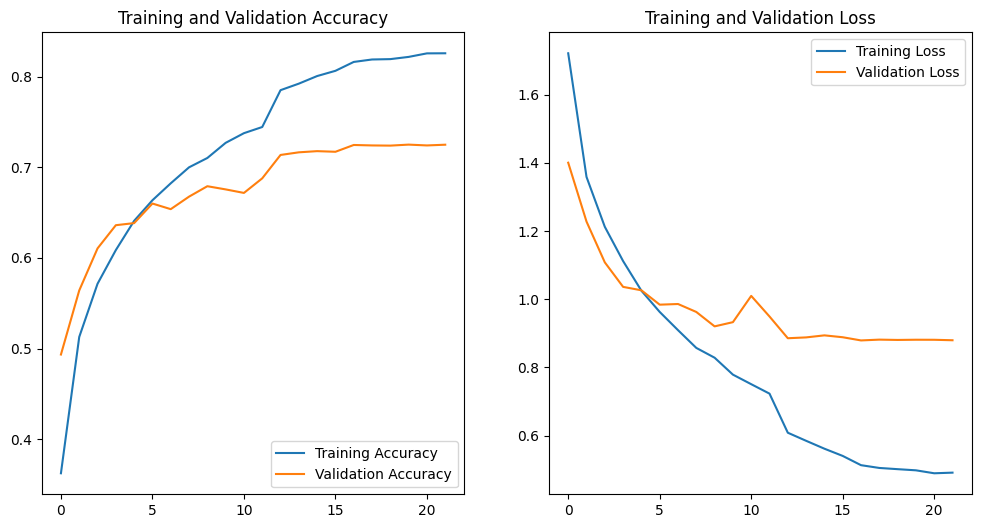

In [14]:
plot_training(history)

In [15]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7255 - loss: 0.8795


In [16]:
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 71.78%


In [44]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [45]:
y_pred_classes = np.argmax(y_pred, axis=1)

In [46]:
y_true = np.argmax(y_test, axis=1)

In [47]:
print(classification_report(y_true, y_pred_classes, target_names=["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]))

              precision    recall  f1-score   support

    airplane       0.74      0.76      0.75      1000
  automobile       0.83      0.85      0.84      1000
        bird       0.61      0.60      0.60      1000
         cat       0.56      0.55      0.55      1000
        deer       0.65      0.64      0.65      1000
         dog       0.63      0.60      0.61      1000
        frog       0.78      0.80      0.79      1000
       horse       0.75      0.75      0.75      1000
        ship       0.83      0.81      0.82      1000
       truck       0.79      0.81      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



In [48]:
conf_matrix = confusion_matrix(y_true, y_pred_classes)

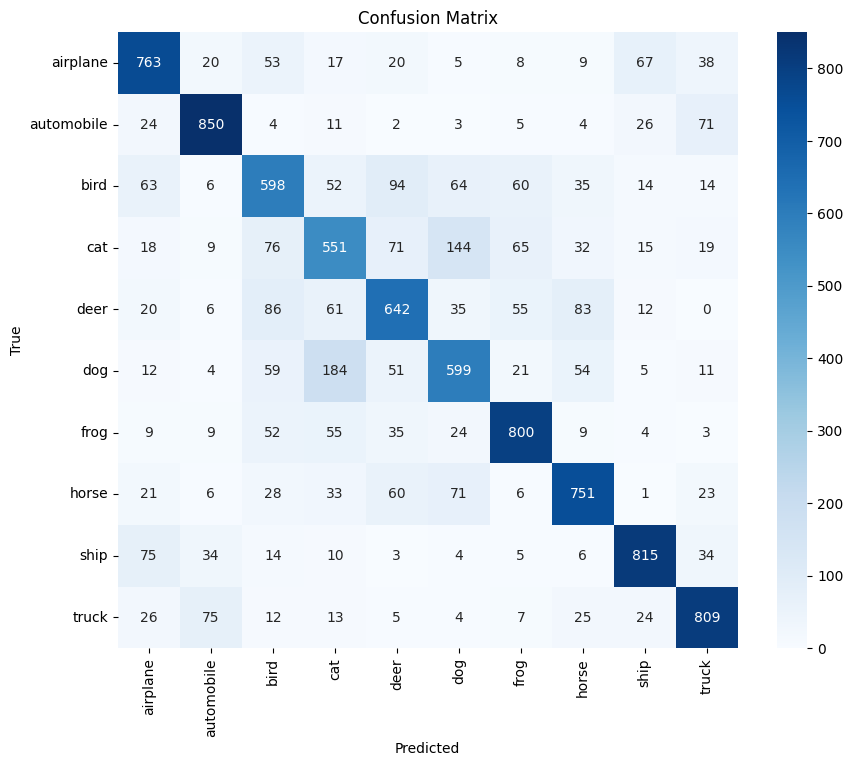

In [49]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"], yticklabels=["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [43]:
model.save("cifar10_image_recognition_model.h5")

In [71]:
def generate_adversarial_example(model, image, label, epsilon=0.01):
    image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
    label_tensor = tf.convert_to_tensor(label, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(image_tensor)
        prediction = model(image_tensor)
        loss = tf.keras.losses.categorical_crossentropy(label_tensor, prediction)
    
    gradient = tape.gradient(loss, image_tensor)
    signed_grad = tf.sign(gradient)
    
    adversarial_image = image_tensor + epsilon * signed_grad
    adversarial_image = tf.clip_by_value(adversarial_image, 0, 1)  # Ensure pixel values are between 0 and 1
    return adversarial_image.numpy()


In [72]:
sample_image = x_test[0:1]
sample_label = y_test[0:1]

In [73]:
adversarial_image = generate_adversarial_example(model, sample_image, sample_label)

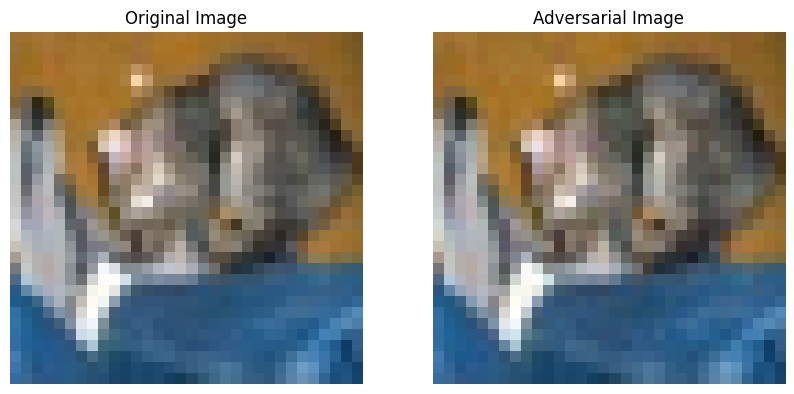

In [74]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(sample_image[0])
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Adversarial Image")
plt.imshow(adversarial_image[0])
plt.axis('off')

plt.show()


In [75]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [76]:
def generate_saliency_map(model, image, label_index):
    image_tensor = tf.convert_to_tensor(image[np.newaxis, ...], dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(image_tensor)
        predictions = model(image_tensor)
        loss = predictions[:, label_index] 

    gradients = tape.gradient(loss, image_tensor)
    saliency_map = tf.reduce_max(tf.abs(gradients), axis=-1)[0]
    saliency_map = (saliency_map - tf.reduce_min(saliency_map)) / (tf.reduce_max(saliency_map) - tf.reduce_min(saliency_map))
    return saliency_map.numpy()



In [77]:
sample_image = x_test[0] 

In [78]:
true_label = np.argmax(y_test[0]) 

In [79]:
saliency_map = generate_saliency_map(model, sample_image, true_label)

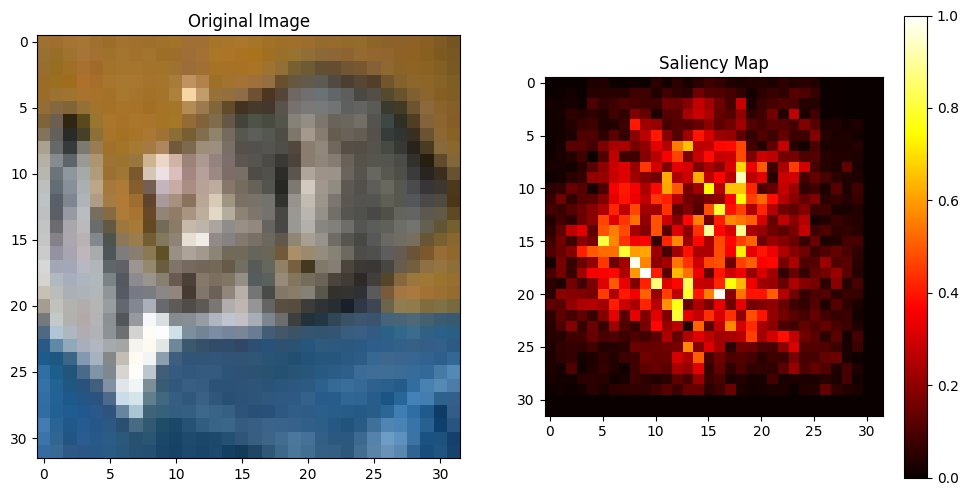

In [81]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(sample_image)
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(saliency_map, cmap='hot')
plt.title("Saliency Map")
plt.colorbar()

plt.show()


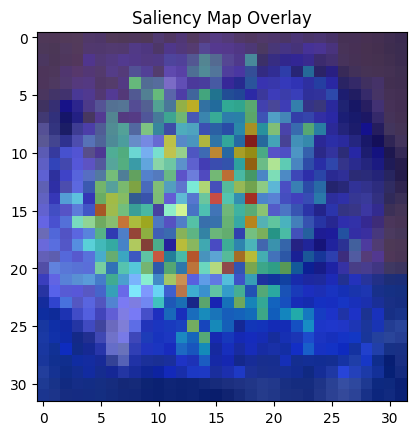

In [60]:
def overlay_saliency_on_image(image, saliency_map):
    saliency_colored = plt.cm.jet(saliency_map)[:, :, :3]  
    overlaid_image = 0.5 * image + 0.5 * saliency_colored 
    return np.clip(overlaid_image, 0, 1) 

In [82]:
overlaid_image = overlay_saliency_on_image(sample_image, saliency_map)

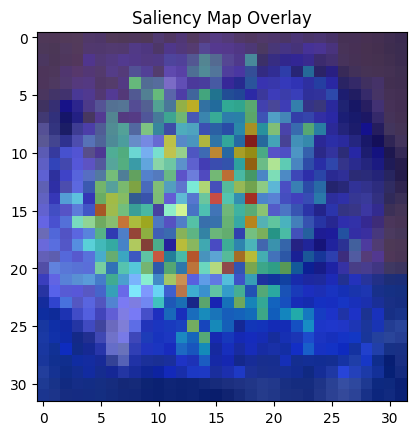

In [83]:
plt.imshow(overlaid_image)
plt.title("Saliency Map Overlay")
plt.show()

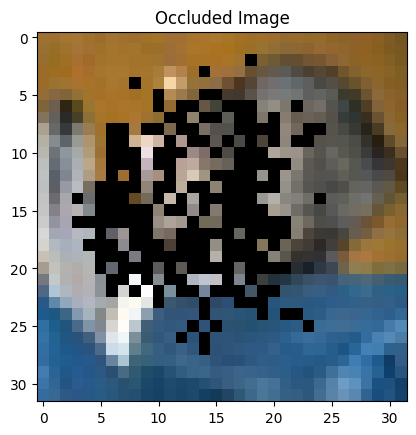

In [62]:
def occlude_image(image, saliency_map, threshold=0.5):
    saliency_flat = saliency_map.flatten()
    num_pixels = int(threshold * saliency_flat.size)
    occlusion_mask = np.argsort(saliency_flat)[-num_pixels:] 
    occluded_image = image.copy()
    occluded_image[np.unravel_index(occlusion_mask, saliency_map.shape)] = 0
    return occluded_image

In [86]:
occluded_img = occlude_image(sample_image, saliency_map, threshold=0.2)

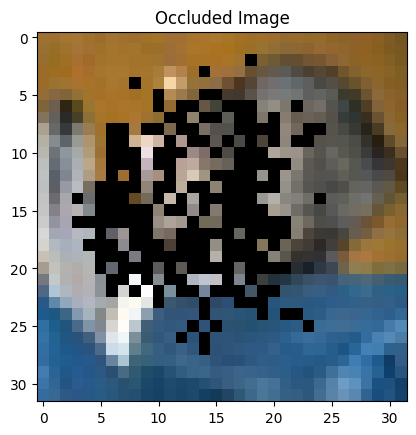

In [87]:
plt.imshow(occluded_img)
plt.title("Occluded Image")
plt.show()

In [69]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



DEPRECATION: Loading egg at c:\program files\python311\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [88]:
pip install dash

Defaulting to user installation because normal site-packages is not writeable
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0
Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\program files\python311\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dtale 3.12.0 requires Flask<2.3; python_version >= "3.7", but you have flask 3.0.3 which is incompatible.


In [97]:
pip install gradio


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/57.6 MB ? eta -:--:--
   - -------------------------------------- 2.1/57.6 MB 9.8 MB/s eta 0:00:06
   --- ------------------------------------ 4.5/57.6 MB 10.7 MB/s eta 0:00:05
   ---- ----------------------------------- 7.1/57.6 MB 10.9 MB/s eta 0:00:05
   ------ --------------------------------- 9.2/57.6 MB 10.8 MB/s eta 0:00:05
   -------- ------------------------------- 11.5/57.6 MB 10.8 MB/s eta 0:00:05
   --------- ------------------------------ 14.2/57.6 MB 10.7 MB/s eta 0:00:05
   ----------- ---------------------------- 16.0/57.6 MB 10.6 MB/s eta 0:00:04
   ------------ --------------------------- 17.3/57.6 MB 10.0 MB/s eta 0:00:05
   ------------ --------------------------- 18.6/57.6 MB 9.4 MB/s eta 0:00:05
   -------------- ------------------------- 20.2/57.6 MB 9.3 MB/s eta 0:00:05
   --------------- ------------------------ 22.0/57.6 MB 9.2 MB/s eta

DEPRECATION: Loading egg at c:\program files\python311\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [108]:
import gradio as gr
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image as keras_image
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

In [109]:
model = load_model('cifar10_image_recognition_model.h5')

In [110]:
def preprocess_image(image):
    image = image.resize((32, 32))
    img = keras_image.img_to_array(image)
    img = np.expand_dims(img, axis=0)
    img = img.astype('float32') / 255.0  
    return img

In [111]:
def generate_saliency_map(model, image_array):
    image_tensor = tf.convert_to_tensor(image_array, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(image_tensor)  
        preds = model(image_tensor)
        class_idx = tf.argmax(preds[0]) 
        class_output = preds[:, class_idx]
    grads = tape.gradient(class_output, image_tensor)
    grads = tf.reduce_mean(tf.abs(grads), axis=-1)  
    saliency_map = np.uint8(255 * grads.numpy())  
    saliency_map = np.squeeze(saliency_map) 
    
    return saliency_map

In [112]:
def process_image(image):
    image_array = preprocess_image(image)
    saliency_map = generate_saliency_map(model, image_array)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(saliency_map, cmap='hot')
    ax.axis('off')
    saliency_map_img = BytesIO()
    plt.savefig(saliency_map_img, format='png')
    saliency_map_img.seek(0)
    saliency_map_base64 = Image.open(saliency_map_img) 
    return image, saliency_map_base64

In [113]:
iface = gr.Interface(
    fn=process_image,
    inputs=gr.Image(type="pil"),  # Input is an image
    outputs=[gr.Image(type="pil"), gr.Image(type="pil")],  # Output: Original image and saliency map
    live=True
)

In [114]:
if __name__ == "__main__":
    iface.launch()


* Running on local URL:  http://127.0.0.1:7867

To create a public link, set `share=True` in `launch()`.
